In [2]:
import pandas as pd, numpy as np
from scipy.stats import gamma, norm, pearson3, anderson, kstest, pearsonr
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
import os, warnings
warnings.filterwarnings('ignore')

PREC_DIR   = r"C:\Users\Apechhya Aryal\Desktop\forpaper\rainfallcorrected"
TEMP_DIR   = r"C:\Users\Apechhya Aryal\Desktop\forpaper\TEMPRATURE_CORRECTED"   # underscore - matches NB2/NB3
OUTPUT_DIR = r"C:\Users\Apechhya Aryal\Desktop\forpaper\drought"
os.makedirs(OUTPUT_DIR, exist_ok=True)
TIMESCALES = [3, 6, 12]

STATIONS = {
    'Jomsom':{'lat':28.78401,'lon':83.72982,'elev':2741},
    'Thakmarpha':{'lat':28.73887,'lon':83.68183,'elev':2655},
    'Lete':{'lat':28.63273,'lon':83.60922,'elev':2490},
    'Ranipauwa':{'lat':28.81556,'lon':83.86222,'elev':3671},
    'Samar_Gaun':{'lat':28.96202,'lon':83.80163,'elev':3610},
    'Dhakarjhong':{'lat':28.82359,'lon':83.73951,'elev':3200},
    'Chhoser':{'lat':29.22713,'lon':83.97982,'elev':3886},
}

def hargreaves_pet(tmax, tmin, lat_deg, doy, scale=1.0):
    """Hargreaves PET (mm/day). Ra is computed in MJ m-2 d-1 then converted to mm/day (x0.408)."""
    lat_rad = np.radians(lat_deg)
    decl = 0.409*np.sin(2*np.pi/365*doy - 1.39)
    ws = np.arccos(np.clip(-np.tan(lat_rad)*np.tan(decl), -1, 1))
    dr = 1 + 0.033*np.cos(2*np.pi/365*doy)
    Ra = (24*60/np.pi)*0.0820*dr*(ws*np.sin(lat_rad)*np.sin(decl) +
                                  np.cos(lat_rad)*np.cos(decl)*np.sin(ws))
    Ra_mm = Ra*0.408                      # <-- MJ m-2 d-1 -> mm/day (the missing conversion)
    pet = 0.0023*scale*Ra_mm*((tmax+tmin)/2 + 17.8)*np.sqrt(np.clip(tmax-tmin, 0, None))
    return np.clip(pet, 0, None)

def compute_spi(monthly_p, ts):
    """SPI: zero-inflated Gamma fit per calendar month on the ts-month accumulation."""
    ac = monthly_p.rolling(window=ts, min_periods=ts).sum()
    spi = pd.Series(np.nan, index=ac.index)
    for m in range(1, 13):
        d = ac[ac.index.month == m].dropna()
        if len(d) < 10: continue
        q0 = (d == 0).sum()/len(d); nz = d[d > 0]
        if len(nz) < 5: continue
        try:
            a, _, sc = gamma.fit(nz, floc=0)
            for i in d.index:
                v = d[i]
                c = q0 if v == 0 else q0 + (1-q0)*gamma.cdf(v, a, loc=0, scale=sc)
                spi[i] = norm.ppf(np.clip(c, 0.001, 0.999))
        except Exception:
            continue
    return spi

def compute_spei(monthly_wb, ts):
    """SPEI: Pearson III fit per calendar month on the ts-month accumulation of P-PET."""
    ac = monthly_wb.rolling(window=ts, min_periods=ts).sum()
    sp = pd.Series(np.nan, index=ac.index)
    for m in range(1, 13):
        d = ac[ac.index.month == m].dropna()
        if len(d) < 10: continue
        try:
            p = pearson3.fit(d)
            for i in d.index:
                sp[i] = norm.ppf(np.clip(pearson3.cdf(d[i], *p), 0.001, 0.999))
        except Exception:
            continue
    return sp

def annual_mean(index_series):
    """Collapse a monthly index series to one value per calendar year (mean of available months)."""
    a = index_series.dropna().resample('YE').mean(); a.index = a.index.year
    return a.dropna()

def pettitt_test(series):
    """Pettitt (1979). APPLY TO ANNUAL series only - overlapping rolling sums break independence."""
    x = np.asarray(series.values, float); n = len(x)
    U = np.array([np.sum(np.sign(x[t] - x)) for t in range(n)])
    S = np.cumsum(U); K = np.max(np.abs(S)); tc = int(np.argmax(np.abs(S)))
    p = min(2*np.exp(-6*K**2/(n**3 + n**2)), 1.0)
    return tc, K, p

def sig_stars(p):
    return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
print("Functions loaded!")

Functions loaded!


In [3]:
station_monthly = {}
for s, meta in STATIONS.items():
    pdf=pd.read_csv(os.path.join(PREC_DIR,f'{s}_precip_corrected.csv'))
    pdf['Date']=pd.to_datetime(pdf['Date']); pdf=pdf.set_index('Date')
    tdf=pd.read_csv(os.path.join(TEMP_DIR,f'{s}_temp_corrected.csv'))
    tdf['Date']=pd.to_datetime(tdf['Date']); tdf=tdf.set_index('Date')
    pet=hargreaves_pet(tdf['Tmax'].values, tdf['Tmin'].values, meta['lat'], tdf.index.dayofyear)
    pm   = pdf['PCPmm_corrected'].resample('ME').sum()
    petm = pd.Series(pet, index=tdf.index).resample('ME').sum()
    station_monthly[s]=pd.DataFrame({'Prec':pm,'PET':petm,'WB':pm-petm})
    nyears = (pm.index.year.max()-pm.index.year.min()+1)
    print(f'  {s:<15} Ann_P={pm.sum()/nyears:5.0f} mm   Ann_PET={petm.sum()/nyears:5.0f} mm   (PET now physically realistic)')

# Documented limitation: Chhoser observed temperature starts ~2005, so its QM (and the
# lapse-rate stations Ranipauwa / Samar_Gaun that depend on it) is extrapolated pre-2005.
_pre = station_monthly['Chhoser']['PET'].loc[:'2004-12-31']
if len(_pre) > 0:
    print(f'  [limitation] Chhoser: {len(_pre)} pre-2005 months rely on extrapolated QM.')

  Jomsom          Ann_P=  289 mm   Ann_PET= 1120 mm   (PET now physically realistic)
  Thakmarpha      Ann_P=  426 mm   Ann_PET= 1067 mm   (PET now physically realistic)
  Lete            Ann_P= 1407 mm   Ann_PET= 1014 mm   (PET now physically realistic)
  Ranipauwa       Ann_P=  294 mm   Ann_PET= 1034 mm   (PET now physically realistic)
  Samar_Gaun      Ann_P=  218 mm   Ann_PET= 1039 mm   (PET now physically realistic)
  Dhakarjhong     Ann_P=  263 mm   Ann_PET= 1079 mm   (PET now physically realistic)
  Chhoser         Ann_P=  277 mm   Ann_PET= 1010 mm   (PET now physically realistic)
  [limitation] Chhoser: 288 pre-2005 months rely on extrapolated QM.


## 4.2 Per-Station + District SPI/SPEI at 3, 6, 12 months

In [4]:
all_spi  = {ts:{} for ts in TIMESCALES}
all_spei = {ts:{} for ts in TIMESCALES}
for s in STATIONS:
    monthly = station_monthly[s]; rows = monthly.copy()
    for ts in TIMESCALES:
        all_spi[ts][s]  = compute_spi(monthly['Prec'], ts)
        all_spei[ts][s] = compute_spei(monthly['WB'],  ts)
        rows[f'SPI_{ts}']  = all_spi[ts][s]
        rows[f'SPEI_{ts}'] = all_spei[ts][s]
    rows.to_csv(os.path.join(OUTPUT_DIR, f'{s}_drought_indices.csv'))

# District: average RAW P and PET first, THEN standardise
dp7   = pd.concat([station_monthly[s]['Prec'] for s in STATIONS], axis=1).mean(axis=1)
dpet7 = pd.concat([station_monthly[s]['PET']  for s in STATIONS], axis=1).mean(axis=1)
dwb7  = dp7 - dpet7

dist_df = pd.DataFrame()
for ts in TIMESCALES:
    dist_df[f'SPI_{ts}']  = compute_spi(dp7, ts)
    dist_df[f'SPEI_{ts}'] = compute_spei(dwb7, ts)
dist_df.to_csv(os.path.join(OUTPUT_DIR, 'Mustang_District_drought_indices.csv'))

print('District drought-month fraction (index < -1):')
for ts in TIMESCALES:
    for col in (f'SPI_{ts}', f'SPEI_{ts}'):
        s = dist_df[col].dropna()
        print(f'  {col:<9} mean={s.mean():+.3f}  std={s.std():.3f}  drought%={(s<-1).mean()*100:4.1f}%')

District drought-month fraction (index < -1):
  SPI_3     mean=-0.005  std=1.000  drought%=14.5%
  SPEI_3    mean=+0.000  std=1.001  drought%=14.5%
  SPI_6     mean=-0.001  std=1.000  drought%=15.6%
  SPEI_6    mean=-0.000  std=1.001  drought%=12.9%
  SPI_12    mean=-0.000  std=1.001  drought%=16.4%
  SPEI_12   mean=+0.000  std=1.001  drought%=13.6%


## 4.3 Goodness-of-Fit per Calendar Month and Timescale

Two checks on the probability-integral transform (PIT): a Kolmogorov-Smirnov test that the PIT values are Uniform(0,1) (the direct test of the fitted distribution), and the Anderson-Darling normality test on the standardised values (kept for continuity). Both use estimated parameters, so they are approximate; we report the count of months passing at the 5% level.

In [5]:
def gof_counts(acc, dist):
    """Return (#months passing KS-uniform, #months passing A-D normal, #months tested) at 5%."""
    ks_pass = ad_pass = tested = 0
    for m in range(1, 13):
        d = acc[acc.index.month == m].dropna()
        if dist == 'gamma':
            d = d[d > 0]
        if len(d) < 10: continue
        tested += 1
        if dist == 'gamma':
            a, _, sc = gamma.fit(d, floc=0); u = gamma.cdf(d, a, loc=0, scale=sc)
        else:
            par = pearson3.fit(d); u = pearson3.cdf(d, *par)
        u = np.clip(u, 1e-6, 1-1e-6)
        if kstest(u, 'uniform').pvalue > 0.05: ks_pass += 1
        z = norm.ppf(u); ad, cv, _ = anderson(z, dist='norm')
        if ad < cv[2]: ad_pass += 1
    return ks_pass, ad_pass, tested

print('Goodness-of-fit (months passing / months tested, 5% level):')
print(f'  {"timescale":<10}{"SPI (Gamma)":>22}{"SPEI (Pearson III)":>24}')
for ts in TIMESCALES:
    acc_p  = dp7.rolling(ts, min_periods=ts).sum().dropna()
    acc_wb = dwb7.rolling(ts, min_periods=ts).sum().dropna()
    ksp, adp, n1 = gof_counts(acc_p,  'gamma')
    ksw, adw, n2 = gof_counts(acc_wb, 'pearson3')
    print(f'  {ts:<10}  KS {ksp}/{n1}, AD {adp}/{n1}{"":6}KS {ksw}/{n2}, AD {adw}/{n2}')

Goodness-of-fit (months passing / months tested, 5% level):
  timescale            SPI (Gamma)      SPEI (Pearson III)
  3           KS 12/12, AD 8/12      KS 12/12, AD 10/12
  6           KS 12/12, AD 11/12      KS 12/12, AD 11/12
  12          KS 12/12, AD 11/12      KS 12/12, AD 12/12


## 4.4 Change-Points (annual) + Signed PET Decomposition

Pettitt is run on the **annual mean** of each index. The water-balance decomposition reports **signed** contributions of the precipitation change and the PET change, which sum exactly to the change in P-PET (so they cannot exceed 100%).

In [6]:
print('Pettitt change-points on ANNUAL index series:')
cp_rows = []
for ts in TIMESCALES:
    for col in (f'SPI_{ts}', f'SPEI_{ts}'):
        a = annual_mean(dist_df[col])
        if len(a) < 10: continue
        tc, K, p = pettitt_test(a); cp = int(a.index[tc])
        before = a.iloc[:tc+1].mean(); after = a.iloc[tc+1:].mean()
        cp_rows.append({'Index':col,'ChangeYear':cp,'p':round(p,5),'Sig':sig_stars(p),
                        'Before':round(before,3),'After':round(after,3),'Shift':round(after-before,3)})
        print(f'  {col:<9} change-year={cp}  shift={after-before:+.3f}  p={p:.4f} {sig_stars(p)}')
pd.DataFrame(cp_rows).to_csv(os.path.join(OUTPUT_DIR,'pettitt_changepoint_annual.csv'), index=False)

# ---- Signed water-balance decomposition around the SPEI-12 change-year ----
cy = next((r['ChangeYear'] for r in cp_rows if r['Index']=='SPEI_12'), 2004)
ann_p   = dp7.resample('YE').sum();   ann_p.index   = ann_p.index.year
ann_pet = dpet7.resample('YE').sum(); ann_pet.index = ann_pet.index.year
pre_p, post_p     = ann_p[ann_p.index < cy].mean(),     ann_p[ann_p.index >= cy].mean()
pre_pet, post_pet = ann_pet[ann_pet.index < cy].mean(), ann_pet[ann_pet.index >= cy].mean()
dP   = post_p - pre_p          # precip change
dPET = post_pet - pre_pet      # PET change
dWB  = dP - dPET               # change in water balance (P - PET)
cP, cPET = dP, -dPET           # signed contributions; cP + cPET == dWB exactly
print(f'\nWater-balance decomposition around {cy} (signed; contributions sum to 100%):')
print(f'  Precip change : {dP:+7.1f} mm  -> contributes {100*cP/dWB:+5.0f}% of the WB change')
print(f'  PET change    : {dPET:+7.1f} mm  -> contributes {100*cPET/dWB:+5.0f}% of the WB change')
print(f'  Net WB change : {dWB:+7.1f} mm   ({"drying" if dWB<0 else "wetting"})')
print('  (A negative contribution means that term acted to OFFSET the WB change.)')

Pettitt change-points on ANNUAL index series:
  SPI_3     change-year=1994  shift=+0.308  p=0.3779 ns
  SPEI_3    change-year=2003  shift=-0.520  p=0.0155 *
  SPI_6     change-year=1993  shift=+0.465  p=0.4406 ns
  SPEI_6    change-year=2003  shift=-0.692  p=0.0353 *
  SPI_12    change-year=1993  shift=+0.620  p=0.3011 ns
  SPEI_12   change-year=2003  shift=-0.871  p=0.0517 ns

Water-balance decomposition around 2003 (signed; contributions sum to 100%):
  Precip change :    -1.3 mm  -> contributes    +2% of the WB change
  PET change    :   +63.6 mm  -> contributes   +98% of the WB change
  Net WB change :   -64.9 mm   (drying)
  (A negative contribution means that term acted to OFFSET the WB change.)


## 4.5 Validation: 3- vs 7-station, Lete exclusion, weighting, PET sensitivity

In [7]:
def spei12_annual_changepoint(p_series, pet_series):
    sp = compute_spei(p_series - pet_series, 12)
    a = annual_mean(sp)
    tc,_,p = pettitt_test(a)
    return a.mean(), int(a.index[tc]), p

# 3-station (QM-only) vs 7-station SPEI-12
QM_STNS=['Jomsom','Lete','Chhoser']
dp3   = pd.concat([station_monthly[s]['Prec'] for s in QM_STNS], axis=1).mean(axis=1)
dpet3 = pd.concat([station_monthly[s]['PET']  for s in QM_STNS], axis=1).mean(axis=1)
spei3 = compute_spei(dp3-dpet3, 12)
mg=pd.concat([spei3, dist_df['SPEI_12']], axis=1).dropna(); mg.columns=['S3','S7']
print(f'3-stn vs 7-stn SPEI-12 monthly correlation: r = {pearsonr(mg["S3"],mg["S7"])[0]:.4f}')

# Lete exclusion
stns_nl=[s for s in STATIONS if s!='Lete']
dp_nl   = pd.concat([station_monthly[s]['Prec'] for s in stns_nl], axis=1).mean(axis=1)
dpet_nl = pd.concat([station_monthly[s]['PET']  for s in stns_nl], axis=1).mean(axis=1)
spei_nl = compute_spei(dp_nl-dpet_nl, 12)
mg2=pd.concat([dist_df['SPEI_12'], spei_nl], axis=1).dropna(); mg2.columns=['7stn','6stn']
print(f'Lete excluded: 7-stn vs 6-stn SPEI-12 r = {pearsonr(mg2["7stn"],mg2["6stn"])[0]:.4f}')

# Spatial weighting sensitivity
from scipy.spatial import distance_matrix
names=list(STATIONS); pts=np.array([[STATIONS[s]['lon'],STATIONS[s]['lat']] for s in names])
dm=distance_matrix(pts,pts); np.fill_diagonal(dm,np.inf)
thiessen_w=dm.min(axis=1)**2; thiessen_w/=thiessen_w.sum()
elevs=np.array([STATIONS[s]['elev'] for s in names]); elev_w=elevs/elevs.sum()
print('\nWeighting sensitivity (SPEI-12, annual change-point):')
for wlabel, w in [('Equal', np.ones(len(names))/len(names)), ('Thiessen', thiessen_w), ('Elevation', elev_w)]:
    dpw   = sum(station_monthly[s]['Prec']*w[j] for j,s in enumerate(names))
    dpetw = sum(station_monthly[s]['PET'] *w[j] for j,s in enumerate(names))
    mean_spei, cp, p = spei12_annual_changepoint(dpw, dpetw)
    print(f'  {wlabel:<10} mean SPEI-12={mean_spei:+.3f}  change-year={cp} (p={p:.4f})')

# PET-magnitude sensitivity: recompute PET at scale x {0.33, 0.66, 1.0}
print('\nPET-magnitude sensitivity (Hargreaves coefficient sweep):')
pet_scaled = {}
for s, meta in STATIONS.items():
    tdf=pd.read_csv(os.path.join(TEMP_DIR,f'{s}_temp_corrected.csv'))
    tdf['Date']=pd.to_datetime(tdf['Date']); tdf=tdf.set_index('Date')
    pet_scaled[s]=tdf
for scale in [0.33, 0.66, 1.0]:
    dps   = dp7
    dpets = pd.concat([
        pd.Series(hargreaves_pet(pet_scaled[s]['Tmax'].values, pet_scaled[s]['Tmin'].values,
                                 STATIONS[s]['lat'], pet_scaled[s].index.dayofyear, scale=scale),
                  index=pet_scaled[s].index).resample('ME').sum()
        for s in STATIONS], axis=1).mean(axis=1)
    mean_spei, cp, p = spei12_annual_changepoint(dps, dpets)
    print(f'  PET x{scale:<5} mean SPEI-12={mean_spei:+.3f}  change-year={cp} (p={p:.4f})')
print('  -> If the drying sign and change-year are stable across scales, the conclusion is PET-robust.')

3-stn vs 7-stn SPEI-12 monthly correlation: r = 0.9571
Lete excluded: 7-stn vs 6-stn SPEI-12 r = 0.9579

Weighting sensitivity (SPEI-12, annual change-point):
  Equal      mean SPEI-12=+0.012  change-year=2003 (p=0.0517)
  Thiessen   mean SPEI-12=+0.038  change-year=2004 (p=0.0025)
  Elevation  mean SPEI-12=+0.013  change-year=2004 (p=0.0202)

PET-magnitude sensitivity (Hargreaves coefficient sweep):
  PET x0.33  mean SPEI-12=-0.081  change-year=1985 (p=0.5246)
  PET x0.66  mean SPEI-12=-0.020  change-year=2003 (p=0.1451)
  PET x1.0   mean SPEI-12=+0.012  change-year=2003 (p=0.0517)
  -> If the drying sign and change-year are stable across scales, the conclusion is PET-robust.


## 4.6 SPI vs SPEI Timelines (3, 6, 12 months)

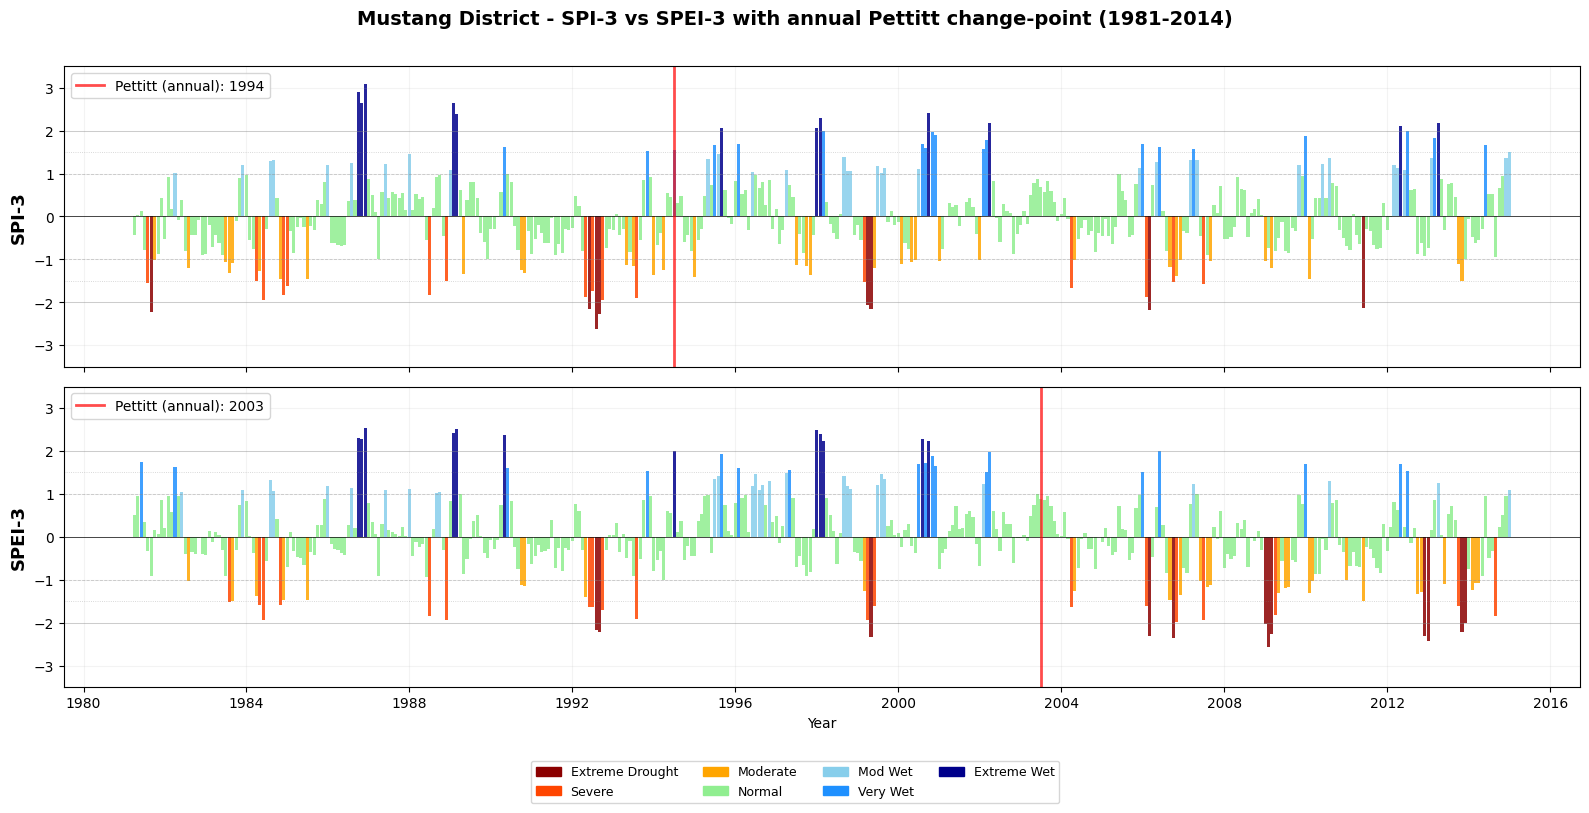

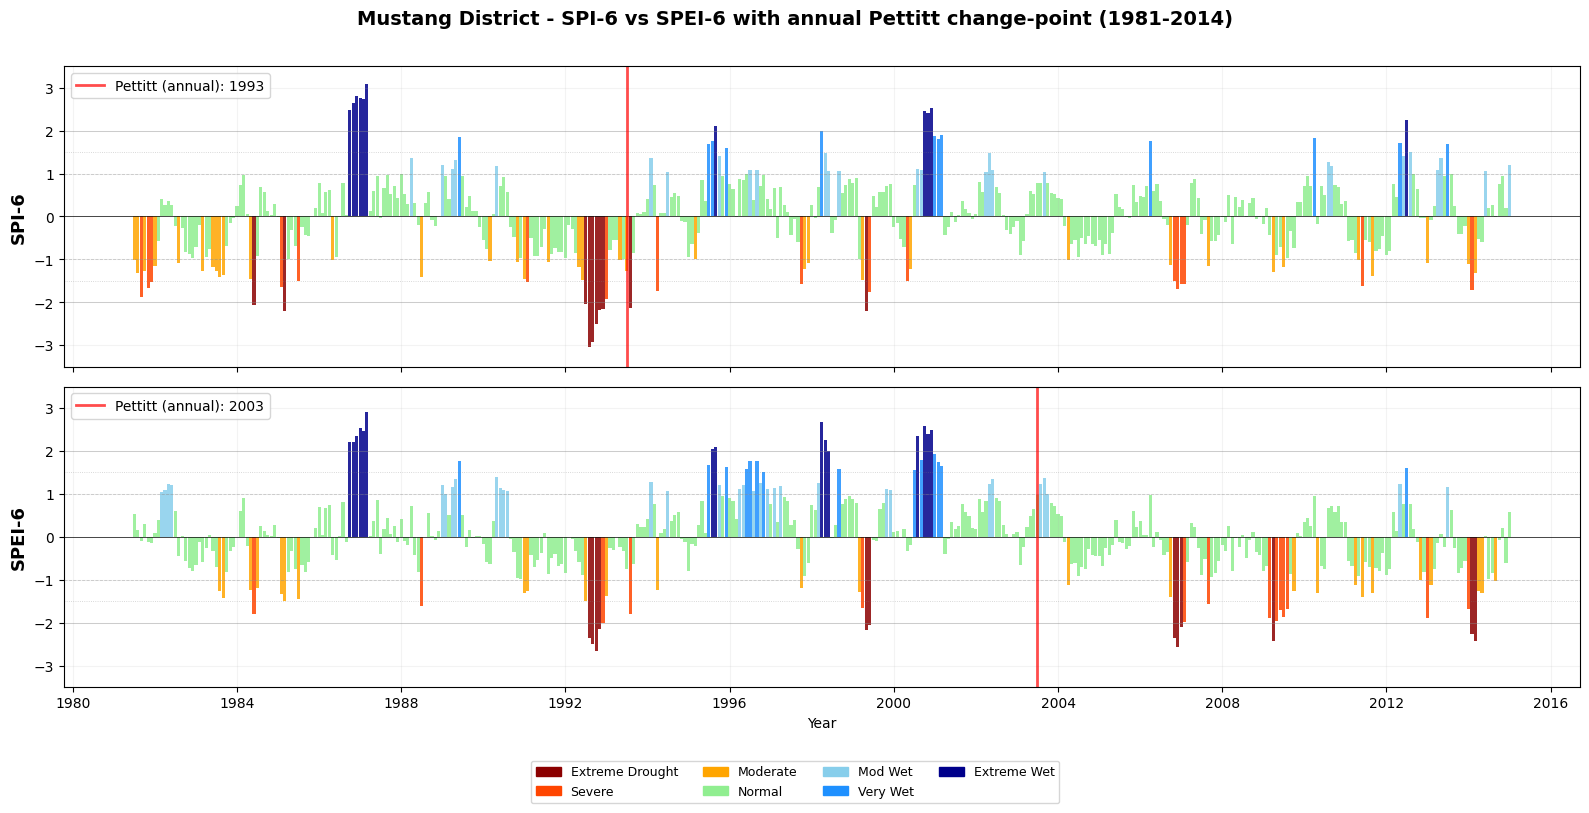

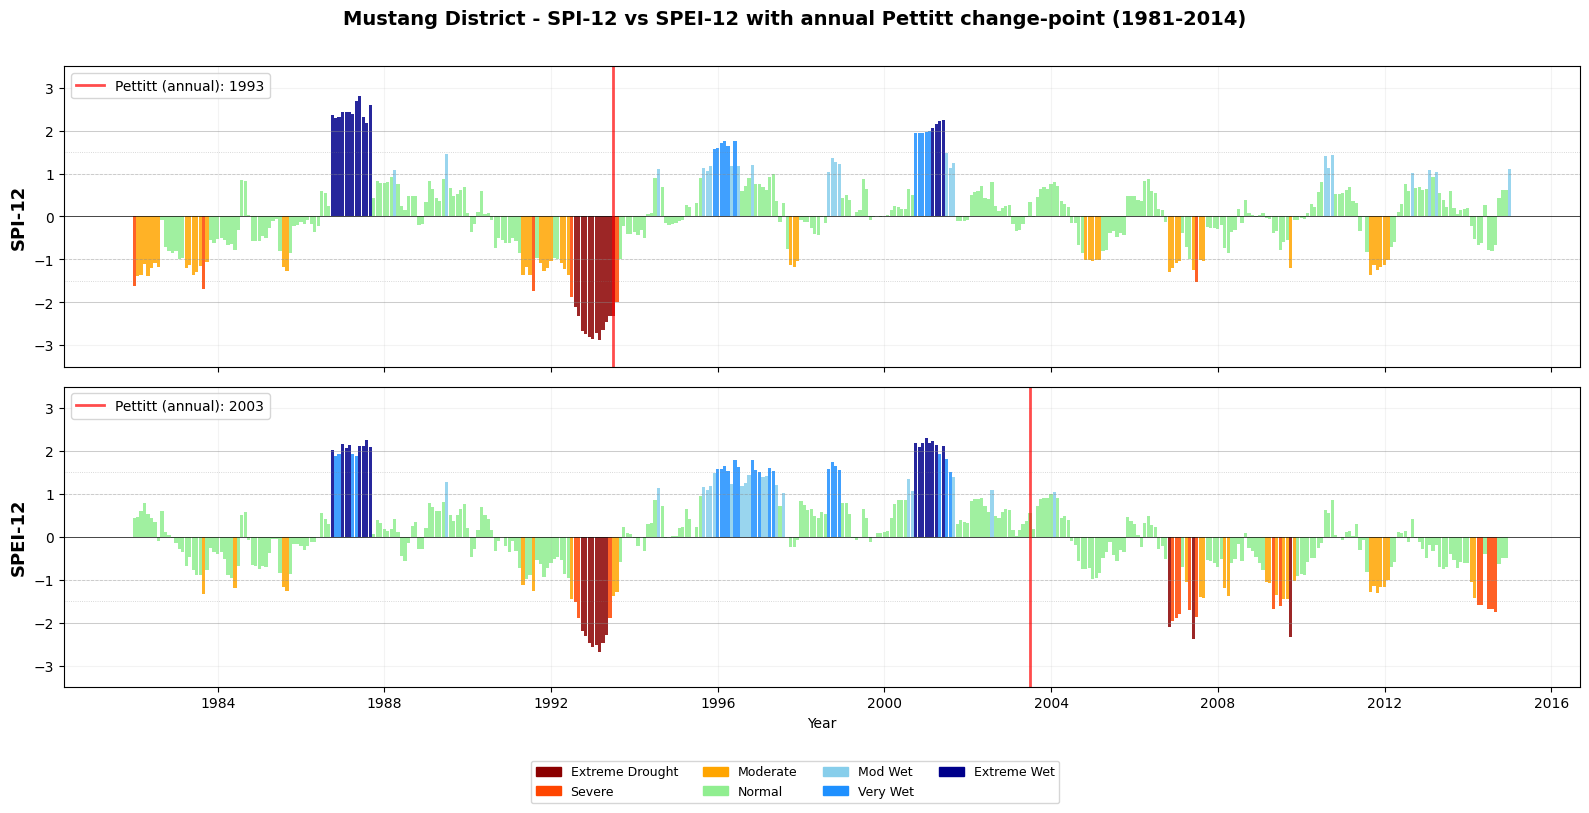

In [8]:
def get_color(v):
    if   v<-2.0: return '#8B0000'
    elif v<-1.5: return '#FF4500'
    elif v<-1.0: return '#FFA500'
    elif v> 2.0: return '#00008B'
    elif v> 1.5: return '#1E90FF'
    elif v> 1.0: return '#87CEEB'
    else:        return '#90EE90'

for ts in TIMESCALES:
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    for ax, (col, label) in zip(axes, [(f'SPI_{ts}', f'SPI-{ts}'), (f'SPEI_{ts}', f'SPEI-{ts}')]):
        series = dist_df[col].dropna()
        ax.bar(series.index, series.values, width=28, color=[get_color(v) for v in series.values], alpha=0.85)
        ax.axhline(0, color='black', lw=0.5)
        for th, st in [(-1,'--'),(-1.5,':'),(-2,'-'),(1,'--'),(1.5,':'),(2,'-')]:
            ax.axhline(th, color='grey', lw=0.6, linestyle=st, alpha=0.4)
        a = annual_mean(series); tc,_,_ = pettitt_test(a); cp = int(a.index[tc])
        ax.axvline(pd.Timestamp(f'{cp}-07-01'), color='red', lw=2, alpha=0.7, label=f'Pettitt (annual): {cp}')
        ax.set_ylabel(label, fontsize=13, fontweight='bold'); ax.set_ylim(-3.5, 3.5)
        ax.grid(True, alpha=0.15); ax.legend(loc='upper left', fontsize=10)
    axes[1].set_xlabel('Year')
    legend=[mpatches.Patch(color=c,label=l) for c,l in [('#8B0000','Extreme Drought'),('#FF4500','Severe'),
        ('#FFA500','Moderate'),('#90EE90','Normal'),('#87CEEB','Mod Wet'),('#1E90FF','Very Wet'),('#00008B','Extreme Wet')]]
    fig.legend(handles=legend, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5,-0.02))
    plt.suptitle(f'Mustang District - SPI-{ts} vs SPEI-{ts} with annual Pettitt change-point (1981-2014)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0,0.06,1,0.97])
    plt.savefig(os.path.join(OUTPUT_DIR, f'drought_timeline_{ts}m.png'), dpi=300, bbox_inches='tight')
    plt.show()